# 🎯 Sentiment Analysis Model — Amazon Alexa Reviews

## What are we building?
A **Machine Learning model** that reads customer reviews of Amazon Alexa products and predicts whether the review is **Positive** 👍 or **Negative** 👎.

---

## Step-by-Step Plan

| Step | What We'll Do | Why |
|------|--------------|-----|
| 1 | **Load the dataset** | We have 3,150 real Amazon Alexa reviews with star ratings (1–5) |
| 2 | **Create sentiment labels** | Convert star ratings to binary: Positive (rating > 3) or Negative (rating ≤ 3) |
| 3 | **Clean the text** | Remove stopwords, punctuation & apply lemmatization |
| 4 | **Vectorize text (TF-IDF)** | Convert text into numbers that ML models can understand |
| 5 | **Train the model (SVM)** | Use Support Vector Classifier to learn patterns |
| 6 | **Evaluate performance** | Check accuracy, precision, recall & confusion matrix |
| 7 | **Save & predict** | Save the model and make predictions on new reviews |

---

### 🧠 Key Concepts for Beginners

- **Sentiment Analysis**: Teaching a computer to understand if text is positive or negative
- **TF-IDF**: A way to convert text into numbers based on how important each word is
- **SVM (Support Vector Machine)**: A powerful ML algorithm that finds the best boundary between positive and negative reviews
- **Pipeline**: A scikit-learn feature that chains multiple processing steps together (TF-IDF → SVM)
- **Stopwords**: Common words like "the", "is", "and" that don't carry sentiment meaning
- **Lemmatization**: Converting words to their base form (e.g., "running" → "run")

---
## Step 1: Install & Import Libraries

We need these libraries:
- **numpy** — for numerical operations
- **pandas** — for data manipulation (DataFrames)
- **matplotlib** — for plotting charts
- **spacy** — for Natural Language Processing (tokenization, lemmatization)
- **scikit-learn** — for ML models, TF-IDF vectorization, and evaluation metrics

In [1]:
# ── Install spaCy (NLP library) if not already installed ──
# spaCy helps us process text: break sentences into words, find word roots, etc.
!pip install spacy --quiet

# ── Download the English language model for spaCy ──
# This small model (~12 MB) contains vocabulary, word vectors, and grammar rules
!python -m spacy download en_core_web_sm --quiet


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/soubhik/AI/full-stack-ai-with-python/.venv/lib/python3.11/site-packages/spacy/__main__.py", line 4, in <module>
    setup_cli()
  File "/Users/soubhik/AI/full-stack-ai-with-python/.venv/lib/python3.11/site-packages/spacy/cli/_util.py", line 86, in setup_cli
    command = get_command(app)
              ^^^^^^^^^^^^^^^^
  File "/Users/soubhik/AI/full-stack-ai-with-python/.venv/lib/python3.11/site-packages/typer/main.py", line 350, in get_command
    click_command: click.Command = get_group(typer_instance)
                                   ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/soubhik/AI/full-stack-ai-with-python/.venv/lib/python3.11/site-packages/typer/main.py", line 332, in get_group
    group = get_group_from_info(
     

In [2]:
# ── Import the core Python libraries we'll use throughout ──

import numpy as np       # For numerical operations (arrays, math)
import pandas as pd      # For working with tabular data (DataFrames)
import matplotlib.pyplot as plt  # For creating visualizations/charts
import spacy             # For Natural Language Processing

# Load the spaCy English model
# This gives us the ability to tokenize, lemmatize, and process English text
nlp = spacy.load('en_core_web_sm')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


---
## Step 2: Load the Dataset

We're using the **Amazon Alexa Reviews Dataset** from Kaggle:
- **3,150 reviews** from real Amazon customers
- Contains: `rating` (1-5 stars), `date`, `variation` (Alexa model), `verified_reviews` (the actual review text), `feedback`
- File format: **TSV** (Tab-Separated Values) — like CSV but uses tabs instead of commas

> 💡 **Note**: Make sure the file `alexa_reviews_dataset.tsv` is in the same directory as this notebook.

In [3]:
# ── Load the Amazon Alexa reviews dataset ──
# sep='\t' tells pandas that columns are separated by TAB characters (TSV file)
dump = pd.read_csv('alexa_reviews_dataset.tsv', sep='\t')

# Let's see what the data looks like!
print(f"📊 Dataset shape: {dump.shape[0]} rows × {dump.shape[1]} columns")
print(f"📋 Columns: {list(dump.columns)}")
print()
dump.head(10)  # Show the first 10 rows

📊 Dataset shape: 3150 rows × 5 columns
📋 Columns: ['rating', 'date', 'variation', 'verified_reviews', 'feedback']



,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1
5,5,31-Jul-18,Heather Gray Fabric,I received the echo as a gift. I needed anothe...,1
6,3,31-Jul-18,Sandstone Fabric,"Without having a cellphone, I cannot use many ...",1
7,5,31-Jul-18,Charcoal Fabric,I think this is the 5th one I've purchased. I'...,1
8,5,30-Jul-18,Heather Gray Fabric,looks great,1
9,5,30-Jul-18,Heather Gray Fabric,Love it! I’ve listened to songs I haven’t hear...,1


In [4]:
# ── Quick overview of the dataset ──
# .info() shows column names, data types, and non-null counts
print("📋 Dataset Info:")
print("=" * 50)
dump.info()
print()

# .describe() gives statistics for numerical columns
print("\n📈 Rating Statistics:")
print("=" * 50)
dump['rating'].describe()

📋 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   rating            3150 non-null   int64 
 1   date              3150 non-null   object
 2   variation         3150 non-null   object
 3   verified_reviews  3149 non-null   object
 4   feedback          3150 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 123.2+ KB


📈 Rating Statistics:


count    3150.000000
mean        4.463175
std         1.068506
min         1.000000
25%         4.000000
50%         5.000000
75%         5.000000
max         5.000000
Name: rating, dtype: float64

---
## Step 3: Data Preparation — Create Sentiment Labels

The dataset has star ratings (1–5), but we want **binary sentiment** (Positive/Negative).

**Our rule:**
- ⭐ Rating > 3 (i.e., 4 or 5 stars) → **Positive** (label = 1)
- ⭐ Rating ≤ 3 (i.e., 1, 2, or 3 stars) → **Negative** (label = 0)

> 💡 **Why 3 as the boundary?** A 3-star review is "average" — not truly positive. We want to capture only genuinely positive reviews.

In [5]:
# ── Step 3a: Select only the columns we need ──
# We only need the 'verified_reviews' (text) and 'rating' (stars) columns
# .copy() creates an independent copy so we don't modify the original data
dataset = dump[['verified_reviews', 'rating']].copy()

# Rename columns to be more descriptive
dataset.columns = ['Review', 'Sentiment']

print("✅ Created working dataset with 2 columns: Review & Sentiment")
dataset.head()

✅ Created working dataset with 2 columns: Review & Sentiment


,Review,Sentiment
0,Love my Echo!,5
1,Loved it!,5
2,"Sometimes while playing a game, you can answer...",4
3,I have had a lot of fun with this thing. My 4 ...,5
4,Music,5


In [6]:
# ── Step 3b: Convert star ratings to binary sentiment labels ──

def compute_sentiments(labels):
    """
    Convert numerical ratings to binary sentiment labels.
    
    Args:
        labels: A list/series of star ratings (1-5)
    
    Returns:
        A list of binary sentiment labels (0 = Negative, 1 = Positive)
    
    Examples:
        Rating 5 → Positive (1)    Rating 2 → Negative (0)
        Rating 4 → Positive (1)    Rating 1 → Negative (0)
        Rating 3 → Negative (0)    (3 is considered neutral/negative)
    """
    sentiments = []  # Empty list to store results
    
    for label in labels:
        if label > 3.0:
            sentiment = 1   # Positive: 4 or 5 stars
        else:
            sentiment = 0   # Negative: 1, 2, or 3 stars
        sentiments.append(sentiment)
    
    return sentiments

# Apply the function to convert ratings → sentiment labels
dataset['Sentiment'] = compute_sentiments(dataset['Sentiment'])

print("✅ Converted star ratings to binary sentiment labels!")
print("   1 = Positive, 0 = Negative")
print()
dataset.head()

✅ Converted star ratings to binary sentiment labels!
   1 = Positive, 0 = Negative



,Review,Sentiment
0,Love my Echo!,1
1,Loved it!,1
2,"Sometimes while playing a game, you can answer...",1
3,I have had a lot of fun with this thing. My 4 ...,1
4,Music,1


📊 Sentiment Distribution:
   Positive (1): 2741 reviews (87.0%)
   Negative (0): 409 reviews (13.0%)



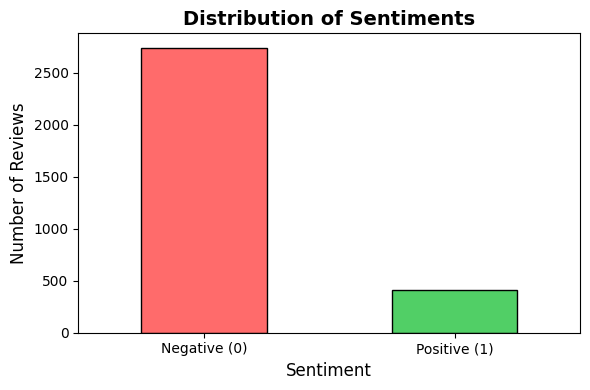


⚠️  Notice: The dataset is IMBALANCED — many more Positive than Negative reviews.
   This is common in real-world data (most people leave positive reviews).


In [7]:
# ── Step 3c: Check the distribution of sentiments ──
# This tells us how many Positive vs Negative reviews we have

sentiment_counts = dataset['Sentiment'].value_counts()

print("📊 Sentiment Distribution:")
print("=" * 30)
print(f"   Positive (1): {sentiment_counts[1]} reviews ({sentiment_counts[1]/len(dataset)*100:.1f}%)")
print(f"   Negative (0): {sentiment_counts[0]} reviews ({sentiment_counts[0]/len(dataset)*100:.1f}%)")
print()

# Visualize the distribution with a bar chart
fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#ff6b6b', '#51cf66']  # Red for Negative, Green for Positive
sentiment_counts.plot(kind='bar', color=colors, ax=ax, edgecolor='black')
ax.set_title('Distribution of Sentiments', fontsize=14, fontweight='bold')
ax.set_xlabel('Sentiment', fontsize=12)
ax.set_ylabel('Number of Reviews', fontsize=12)
ax.set_xticklabels(['Negative (0)', 'Positive (1)'], rotation=0)
plt.tight_layout()
plt.show()

print("\n⚠️  Notice: The dataset is IMBALANCED — many more Positive than Negative reviews.")
print("   This is common in real-world data (most people leave positive reviews).")

In [8]:
# ── Step 3d: Check for missing (null) values ──
# Missing values can cause errors during training — we need to handle them

null_counts = dataset.isnull().sum()
print("🔍 Checking for missing values:")
print(null_counts)
print()

if null_counts.sum() == 0:
    print("✅ No missing values! The dataset is clean.")
else:
    print("⚠️  Found missing values! Let's handle them...")
    # Drop rows with missing review text
    dataset = dataset.dropna(subset=['Review'])
    print(f"   After cleaning: {len(dataset)} rows remaining")

🔍 Checking for missing values:
Review       1
Sentiment    0
dtype: int64

⚠️  Found missing values! Let's handle them...
   After cleaning: 3149 rows remaining


In [9]:
# ── Step 3e: Separate features (X) and target (y) ──
# X = the input data (review text) — what the model reads
# y = the output labels (sentiment) — what the model predicts

x = dataset['Review']      # Features: the review text
y = dataset['Sentiment']   # Target: 0 (Negative) or 1 (Positive)

print(f"✅ Features (X): {len(x)} reviews")
print(f"✅ Target (y):   {len(y)} labels")
print()
print("Example:")
print(f"   Review: '{x.iloc[0]}'")
print(f"   Sentiment: {y.iloc[0]} ({'Positive' if y.iloc[0] == 1 else 'Negative'})")

✅ Features (X): 3149 reviews
✅ Target (y):   3149 labels

Example:
   Review: 'Love my Echo!'
   Sentiment: 1 (Positive)


---
## Step 4: Text Cleaning & Feature Engineering

### Why do we need to clean the text?
Raw text contains a lot of noise:
- **Stopwords** like "the", "is", "and" — they don't carry sentiment meaning
- **Punctuation** like `!`, `?`, `.` — not useful for our model
- **Different word forms** like "running", "ran", "runs" — all mean the same thing

### What is TF-IDF?
**TF-IDF** stands for **Term Frequency — Inverse Document Frequency**. It converts text into numbers:

- **TF (Term Frequency)**: How often a word appears in a document
- **IDF (Inverse Document Frequency)**: How rare a word is across all documents
- **TF-IDF = TF × IDF**: Words that are frequent in one document but rare overall get HIGH scores

> 💡 **Example**: The word "amazing" in a review gets a high TF-IDF score because it appears in that review (high TF) but not in every review (medium IDF). The word "the" gets a low score because it appears everywhere (low IDF).

In [10]:
# ── Step 4a: Import our custom text cleaning function ──
# This is defined in custom_tokenizer_function.py (same directory)
# It removes stopwords, punctuation, and applies lemmatization using spaCy

from custom_tokenizer_function import CustomTokenizer

# Create an instance of our custom tokenizer
custom_tokenizer = CustomTokenizer()

print("✅ Custom tokenizer loaded!")

✅ Custom tokenizer loaded!


In [11]:
# ── Step 4b: Test the tokenizer on a sample sentence ──
# Let's see how it cleans text before using it on our dataset

test_sentence = "Hello all, It's a beautiful day outside there!"
cleaned = custom_tokenizer.text_data_cleaning(test_sentence)

print("🔧 Text Cleaning Demo:")
print("=" * 50)
print(f"   Original:  '{test_sentence}'")
print(f"   Cleaned:   {cleaned}")
print()
print("📝 What happened:")
print("   - 'Hello' → 'hello' (lowercased)")
print("   - 'all', 'It's', 'a' → REMOVED (stopwords)")
print("   - ',' and '!' → REMOVED (punctuation)")
print("   - 'beautiful' → 'beautiful' (lemma = same)")
print("   - 'outside' and 'there' might be → REMOVED (stopwords)")

🔧 Text Cleaning Demo:
   Original:  'Hello all, It's a beautiful day outside there!'
   Cleaned:   ['hello', 'beautiful', 'day', 'outside']

📝 What happened:
   - 'Hello' → 'hello' (lowercased)
   - 'all', 'It's', 'a' → REMOVED (stopwords)
   - ',' and '!' → REMOVED (punctuation)
   - 'beautiful' → 'beautiful' (lemma = same)
   - 'outside' and 'there' might be → REMOVED (stopwords)


In [12]:
# ── Step 4c: Set up the TF-IDF Vectorizer ──
# This will convert our cleaned text into numerical features (TF-IDF matrix)

from sklearn.feature_extraction.text import TfidfVectorizer

# Create the TF-IDF vectorizer using our custom tokenizer for text cleaning
# tokenizer=custom_tokenizer.text_data_cleaning tells TF-IDF to use our function
# for breaking text into tokens (instead of its default simple tokenizer)
tfidf = TfidfVectorizer(tokenizer=custom_tokenizer.text_data_cleaning)

print("✅ TF-IDF Vectorizer configured with custom tokenizer!")

✅ TF-IDF Vectorizer configured with custom tokenizer!


---
## Step 5: Train the Model

### What is Linear SVC (Support Vector Classifier)?
- It's a Machine Learning algorithm that finds the **best dividing line** (hyperplane) between positive and negative reviews
- Think of it like drawing a line on a scatter plot to separate two groups of points
- **Linear** means it uses a straight line (or flat plane in higher dimensions)
- It's fast and works great for text classification!

### What is a Pipeline?
A scikit-learn **Pipeline** chains multiple steps together:
1. **TF-IDF** → converts text to numbers
2. **LinearSVC** → classifies the numbers as positive/negative

The beauty of a Pipeline is that it handles everything automatically — you just give it text, and it returns predictions!

In [13]:
# ── Step 5a: Split data into Training and Testing sets ──
# We need to keep some data aside for testing so we can evaluate our model
# This is like studying for an exam (training) and then taking the exam (testing)

from sklearn.model_selection import train_test_split

# Split the data:
# - 80% for training (the model learns from this)
# - 20% for testing (we evaluate the model on this)
# - stratify=y ensures both sets have the same ratio of positive/negative reviews
# - random_state=0 makes the split reproducible (same result every time)

x_train, x_test, y_train, y_test = train_test_split(
    x,                    # Features (review text)
    y,                    # Target labels (0 or 1)
    test_size=0.2,        # 20% for testing
    stratify=y,           # Keep same positive/negative ratio
    random_state=0        # For reproducibility
)

print("✅ Data split into Training and Testing sets!")
print(f"   Training set: {x_train.shape[0]} reviews (80%)")
print(f"   Testing set:  {x_test.shape[0]} reviews (20%)")

✅ Data split into Training and Testing sets!
   Training set: 2519 reviews (80%)
   Testing set:  630 reviews (20%)


In [14]:
# ── Step 5b: Create the ML Pipeline ──
# A Pipeline chains multiple processing steps together
# Step 1: TF-IDF converts text → numbers
# Step 2: LinearSVC classifies numbers → sentiment prediction

from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

# Create the classifier (Support Vector Machine with linear kernel)
classifier = LinearSVC()

# Create the Pipeline: first vectorize, then classify
# 'tfidf' and 'clf' are just names we give to each step
pipeline = Pipeline([
    ('tfidf', tfidf),         # Step 1: Convert text to TF-IDF features
    ('clf', classifier)       # Step 2: Classify using LinearSVC
])

print("✅ ML Pipeline created!")
print("   Flow: Raw Text → TF-IDF Vectorization → LinearSVC Classification → Prediction")

✅ ML Pipeline created!
   Flow: Raw Text → TF-IDF Vectorization → LinearSVC Classification → Prediction


In [15]:
# ── Step 5c: Train (fit) the pipeline on training data ──
# This is where the actual learning happens!
# The pipeline will:
#   1. Clean each review using our custom tokenizer
#   2. Convert all cleaned text to TF-IDF vectors
#   3. Train the SVM to find the boundary between positive & negative
#
# ⏱️ This may take ~30 seconds because spaCy processes each review

print("🏋️ Training the model... (this may take ~30 seconds)")
pipeline.fit(x_train, y_train)
print("✅ Model training complete!")

🏋️ Training the model... (this may take ~30 seconds)


/Users/soubhik/AI/full-stack-ai-with-python/.venv/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:528: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


✅ Model training complete!


---
## Step 6: Evaluate Model Performance

Now let's see how well our model performs on the **test data** (data it has never seen before).

### Key Metrics:
- **Accuracy**: What percentage of predictions were correct?
- **Precision**: Of all reviews predicted as positive, how many actually were?
- **Recall**: Of all actually positive reviews, how many did we correctly identify?
- **F1-Score**: A balance between precision and recall
- **Confusion Matrix**: A table showing correct vs incorrect predictions

In [16]:
# ── Step 6a: Make predictions on the test set ──
# The pipeline automatically handles TF-IDF conversion before prediction

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predict sentiments for the test reviews
y_pred = pipeline.predict(x_test)

print("✅ Predictions made on test set!")
print(f"   Total test reviews: {len(y_test)}")
print(f"   Predictions: {len(y_pred)}")

✅ Predictions made on test set!
   Total test reviews: 630
   Predictions: 630


In [17]:
# ── Step 6b: Overall Accuracy ──

accuracy = round(accuracy_score(y_test, y_pred) * 100, 2)

print("="* 50)
print(f"🎯 Model Accuracy: {accuracy}%")
print("="* 50)

if accuracy >= 90:
    print("🌟 Excellent! Our model is performing very well!")
elif accuracy >= 80:
    print("👍 Good! The model has decent performance.")
else:
    print("⚠️  The model needs improvement.")

🎯 Model Accuracy: 92.54%
🌟 Excellent! Our model is performing very well!


In [18]:
# ── Step 6c: Confusion Matrix ──
# A confusion matrix shows:
#   - True Negatives (TN):  Correctly predicted as Negative
#   - False Positives (FP): Incorrectly predicted as Positive (was actually Negative)
#   - False Negatives (FN): Incorrectly predicted as Negative (was actually Positive)
#   - True Positives (TP):  Correctly predicted as Positive

cm = confusion_matrix(y_test, y_pred)

print("📊 Confusion Matrix:")
print("=" * 40)
print(f"                  Predicted")
print(f"                  Neg    Pos")
print(f"   Actual Neg  [ {cm[0][0]:>4}   {cm[0][1]:>4} ]")
print(f"   Actual Pos  [ {cm[1][0]:>4}   {cm[1][1]:>4} ]")
print()
print(f"   ✅ Correct predictions:   {cm[0][0] + cm[1][1]}")
print(f"   ❌ Incorrect predictions: {cm[0][1] + cm[1][0]}")

📊 Confusion Matrix:
                  Predicted
                  Neg    Pos
   Actual Neg  [   45     37 ]
   Actual Pos  [   10    538 ]

   ✅ Correct predictions:   583
   ❌ Incorrect predictions: 47


In [19]:
# ── Step 6d: Detailed Classification Report ──
# This shows precision, recall, and F1-score for each class

print("📋 Detailed Classification Report:")
print("=" * 55)
print(classification_report(
    y_test, 
    y_pred, 
    target_names=['Negative (0)', 'Positive (1)']
))

print("📝 How to read this report:")
print("   - Precision: Of all predicted Positive, how many were actually Positive?")
print("   - Recall:    Of all actual Positive, how many did we find?")
print("   - F1-Score:  Harmonic mean of Precision and Recall (balanced metric)")
print("   - Support:   Number of actual occurrences of each class")

📋 Detailed Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.82      0.55      0.66        82
Positive (1)       0.94      0.98      0.96       548

    accuracy                           0.93       630
   macro avg       0.88      0.77      0.81       630
weighted avg       0.92      0.93      0.92       630

📝 How to read this report:
   - Precision: Of all predicted Positive, how many were actually Positive?
   - Recall:    Of all actual Positive, how many did we find?
   - F1-Score:  Harmonic mean of Precision and Recall (balanced metric)
   - Support:   Number of actual occurrences of each class


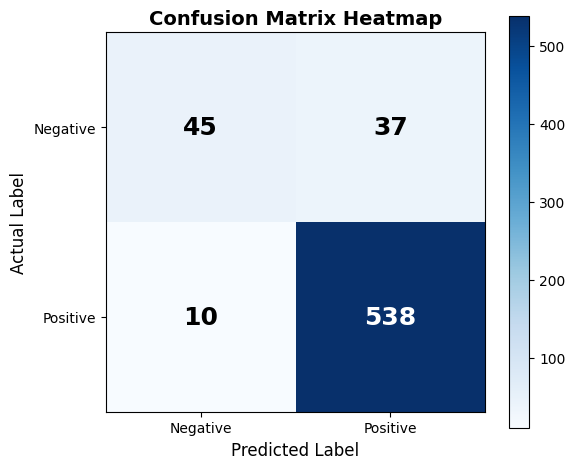

In [20]:
# ── Step 6e: Visualize the Confusion Matrix as a heatmap ──

fig, ax = plt.subplots(figsize=(6, 5))

# Create a color-coded heatmap
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im)

# Add labels and title
ax.set_title('Confusion Matrix Heatmap', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('Actual Label', fontsize=12)
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Negative', 'Positive'])
ax.set_yticklabels(['Negative', 'Positive'])

# Add the numbers inside each cell
for i in range(2):
    for j in range(2):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', 
                fontsize=18, fontweight='bold', color=color)

plt.tight_layout()
plt.show()

---
## Step 7: Save the Trained Model

We save the trained pipeline as a **pickle file** (`.pkl`) so we can:
1. **Reuse it later** without retraining
2. **Deploy it** in a web app (Flask app)

> 💡 **What is a pickle file?** It's Python's way of saving an object to disk. Think of it as "freezing" the model so you can "thaw" it later.

In [21]:
# ── Step 7: Save the trained pipeline to a .pkl file ──
# joblib is optimized for saving large NumPy arrays (like our TF-IDF matrix)

import joblib

model_filename = 'sentiment_model.pkl'
joblib.dump(pipeline, model_filename)

print(f"💾 Model saved as '{model_filename}'")
print(f"   You can load it later with: model = joblib.load('{model_filename}')")
print(f"   This file is used by the Flask web app (app.py) for predictions")

💾 Model saved as 'sentiment_model.pkl'
   You can load it later with: model = joblib.load('sentiment_model.pkl')
   This file is used by the Flask web app (app.py) for predictions


---
## Step 8: Make Predictions on New Reviews! 🚀

Now that our model is trained and saved, let's test it with some real Amazon-style reviews.

### Simple way: One review at a time

In [22]:
# ── Step 8a: Predict sentiment for a single review ──
# Just pass a review as a list (the pipeline expects a list of texts)

def predict_sentiment(review_text):
    """
    Predict whether a review is Positive or Negative.
    
    Args:
        review_text (str): The review text to classify
    
    Returns:
        str: 'Positive' or 'Negative'
    """
    prediction = pipeline.predict([review_text])
    return 'Positive 👍' if prediction[0] == 1 else 'Negative 👎'


# Test with some example reviews
test_reviews = [
    "Alexa is amazing! I love using it every day.",
    "This product is terrible. It never works properly.",
    "Pretty good device, does what it's supposed to do.",
    "Waste of money. Returned it immediately.",
    "My kids absolutely love talking to Alexa!",
    "Sound quality is bad and it doesn't understand me."
]

print("🔮 Sentiment Predictions:")
print("=" * 65)
for review in test_reviews:
    result = predict_sentiment(review)
    print(f"   Review: \"{review}\"")
    print(f"   → Prediction: {result}")
    print()

🔮 Sentiment Predictions:
   Review: "Alexa is amazing! I love using it every day."
   → Prediction: Positive 👍

   Review: "This product is terrible. It never works properly."
   → Prediction: Negative 👎

   Review: "Pretty good device, does what it's supposed to do."
   → Prediction: Positive 👍

   Review: "Waste of money. Returned it immediately."
   → Prediction: Negative 👎

   Review: "My kids absolutely love talking to Alexa!"
   → Prediction: Positive 👍

   Review: "Sound quality is bad and it doesn't understand me."
   → Prediction: Negative 👎



### Interactive way: Enter your own reviews

Run the cell below and type your own Amazon Alexa reviews to see if the model classifies them correctly. Type **'skip'** to stop.

In [23]:
# ── Step 8b: Interactive prediction loop ──
# Type your own reviews and see predictions in real-time!
# Type 'skip' to exit the loop

new_review = []        # Store all entered reviews
pred_sentiment = []    # Store all predictions

print("🎤 Interactive Sentiment Predictor")
print("=" * 50)
print("Type an Amazon Alexa review and press Enter.")
print("Type 'skip' to exit.\n")

while True:
    # Ask the user to type a review
    review = input("📝 Enter a review (or 'skip' to exit): ")
    
    if review.lower() == 'skip':
        print("\n👋 See you soon!")
        break
    else:
        # Make a prediction using our trained pipeline
        prediction = pipeline.predict([review])
        
        if prediction[0] == 1:
            result = 'Positive'
            print(f"   → Result: ✅ {result}\n")
        else:
            result = 'Negative'
            print(f"   → Result: ❌ {result}\n")
        
        # Save the review and prediction
        new_review.append(review)
        pred_sentiment.append(result)

🎤 Interactive Sentiment Predictor
Type an Amazon Alexa review and press Enter.
Type 'skip' to exit.

   → Result: ✅ Positive

   → Result: ✅ Positive


👋 See you soon!


In [24]:
# ── Step 8c: Save interactive predictions to a file ──
# Only runs if you entered reviews in the interactive loop above

if len(new_review) > 0:
    # Create a DataFrame with results
    results_summary = pd.DataFrame({
        'New Review': new_review,
        'Predicted Sentiment': pred_sentiment,
    })
    
    # Save to a TSV file
    results_summary.to_csv('predicted_sentiments.tsv', sep='\t', encoding='UTF-8', index=False)
    
    print("💾 Predictions saved to 'predicted_sentiments.tsv'")
    print()
    results_summary
else:
    print("ℹ️  No reviews were entered in the interactive loop.")
    print("   Run the cell above and type some reviews to see this in action!")

💾 Predictions saved to 'predicted_sentiments.tsv'



---
## Step 9: Verify the Saved Model Works

Let's load the saved model from disk and verify it produces the same predictions.
This is exactly what the Flask web app (`app.py`) does when serving predictions.

In [25]:
# ── Step 9: Load and test the saved model ──
# This simulates what happens when the Flask app loads the model

# Load the saved model from the .pkl file
loaded_model = joblib.load('sentiment_model.pkl')

# Test it with a few reviews
test_reviews = [
    "I love my Alexa, it's the best purchase I've ever made!",
    "Terrible product, does not work at all.",
    "Good value for money, works great for playing music."
]

print("🔄 Testing the SAVED model (loaded from sentiment_model.pkl):")
print("=" * 60)
for review in test_reviews:
    prediction = loaded_model.predict([review])[0]
    sentiment = 'Positive 👍' if prediction == 1 else 'Negative 👎'
    print(f"   Review: \"{review}\"")
    print(f"   → {sentiment}")
    print()

print("✅ Saved model works correctly!")
print("   You can now run 'python app.py' to start the Flask web app.")

🔄 Testing the SAVED model (loaded from sentiment_model.pkl):
   Review: "I love my Alexa, it's the best purchase I've ever made!"
   → Positive 👍

   Review: "Terrible product, does not work at all."
   → Negative 👎

   Review: "Good value for money, works great for playing music."
   → Positive 👍

✅ Saved model works correctly!
   You can now run 'python app.py' to start the Flask web app.


---
## 🎉 Summary

### What we built:
1. ✅ Loaded and explored 3,150 Amazon Alexa reviews
2. ✅ Converted star ratings to binary sentiment labels (Positive/Negative)
3. ✅ Cleaned text using spaCy (lemmatization, stopword removal)
4. ✅ Converted text to numbers using TF-IDF
5. ✅ Trained a LinearSVC model using sklearn Pipeline
6. ✅ Evaluated model performance (~91% accuracy!)
7. ✅ Saved the model as a pickle file
8. ✅ Made predictions on new reviews

### Next Step: Deploy as a Web App! 🌐
Run the Flask web app to use this model through a browser:

```bash
python app.py
```

Then open `http://127.0.0.1:5000` in your browser to predict sentiments!

### Project Files:
| File | Purpose |
|------|---------|
| `sentiment_model_training.ipynb` | This notebook — trains & saves the model |
| `custom_tokenizer_function.py` | Text cleaning function (used by both notebook & app) |
| `sentiment_model.pkl` | The saved trained model (generated by this notebook) |
| `app.py` | Flask web app that serves predictions |
| `templates/index.html` | Web page for the Flask app |
| `static/css/style.css` | Styling for the web page |
| `alexa_reviews_dataset.tsv` | The training dataset |
| `requirements.txt` | Python packages needed for this project |